# Visualization API

### This notebook provides a Visualization and debugging tools of SysVar. This follows the previous example in Sysvar 101 example.

### Create a pseudo-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sample_size = 2000
theta =  5.5
momentum_scaler =MinMaxScaler((0.05, 0.4))
momentum_scaler.fit(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1))
toy_df = pd.DataFrame(
    {
        "channel": np.random.randint(0, 2, sample_size), # Assume 4 reco channels,
        "template": np.random.randint(1, 3, sample_size), # Assume 2 templates, 1 = signal and 2 = BKG
        "slow_pi_p": momentum_scaler.transform(np.random.gamma(theta, 1.0, sample_size).reshape(-1, 1)).flatten(),
    }
)

toy_df["slow_pi_mcPDG"] =  np.random.choice([-211, 211], sample_size)
toy_df["slow_pi_PDG"] =  np.random.choice([-211, 211], sample_size)

toy_df.loc[toy_df.template == 1, "fit_variable1"] = np.random.exponential(0.2, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "fit_variable2"] = np.random.normal(2.5, 0.3, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 1, "other_weight"] = np.random.normal(0.3, 0.04, len(toy_df[toy_df.template == 1]))
toy_df.loc[toy_df.template == 2, "fit_variable1"] = np.random.power(1.5, len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "fit_variable2"] = np.random.rayleigh(1.5, size = len(toy_df[toy_df.template == 2]))
toy_df.loc[toy_df.template == 2, "other_weight"] = np.random.normal(0.8, 0.1, len(toy_df[toy_df.template == 2]))

toy_df = toy_df.query("0 < fit_variable1 < 1")
toy_df = toy_df.query("1 < fit_variable2 < 4")
toy_df = toy_df.query("0.05 < slow_pi_p < 0.4")

toy_df["template"].replace(1, "signal", inplace = True)
toy_df["template"].replace(2, "bkg", inplace = True)

toy_df


/var/folders/pv/0jgqndwd687_skyjt_y0d0n40000gn/T/ipykernel_20952/3852645192.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  toy_df["template"].replace(1, "signal", inplace = True)


,channel,template,slow_pi_p,slow_pi_mcPDG,slow_pi_PDG,fit_variable1,fit_variable2,other_weight
0,1,signal,0.172051,-211,211,0.134605,2.795763,0.312629
1,0,bkg,0.107327,211,-211,0.369930,1.794089,0.623501
2,0,signal,0.165115,211,-211,0.251964,2.702769,0.302462
3,0,signal,0.168345,211,-211,0.115587,2.289204,0.263259
7,1,signal,0.130042,-211,211,0.060694,2.678528,0.224296
...,...,...,...,...,...,...,...,...
1995,1,signal,0.172151,-211,211,0.037016,2.976595,0.216264
1996,1,bkg,0.124107,211,211,0.539723,2.129137,0.829801
1997,1,signal,0.129063,-211,-211,0.025201,1.751683,0.331777
1998,0,bkg,0.174459,-211,-211,0.605389,2.450404,0.685608


### Now let's add slow pion weights to the dataframe

### Information necessary in the dataframe for charged slow pion:
Looking at the config file for charged_slow_pion corrections-

1. dependent variable: p
2. extra_cuts: PDG

These are the basf2 variable information required in the dataframe for this correction to work. A prefix can be chosen to distinguish between different particles or also can be provided as a list of prefices. Here a prefix 'slow_pi' is provided. This requires the dataframe to have variables 'slow_pi_p', 'slow_pi_PDG' to exist. Weightname for the corresponding correction is also required and a prefix if provided is again prepended. Therefore, 'slow_pi_charged_weight' is also required in the dataframe and has been added in the example already.


In [2]:
from sysvar import add_weights_to_dataframe

add_weights_to_dataframe(
    df = toy_df,
    systematic= "charged_slow_pi",
    MC_production= "sysvar_101",
    prefix= "slow_pi",
    weightname ="charged_weight",
    #overwrite: False,
    #Nvar: 0
)
toy_df

INFO : read_corrections: 392 :  Loading correction values from config array.
INFO : add_weights_to_dataframe: 103 :  slow_pi_charged_weight does not exist. Adding it to dataframe


,channel,template,slow_pi_p,slow_pi_mcPDG,slow_pi_PDG,fit_variable1,fit_variable2,other_weight,slow_pi_charged_weight
0,1,signal,0.172051,-211,211,0.134605,2.795763,0.312629,0.943
1,0,bkg,0.107327,211,-211,0.369930,1.794089,0.623501,0.977
2,0,signal,0.165115,211,-211,0.251964,2.702769,0.302462,0.943
3,0,signal,0.168345,211,-211,0.115587,2.289204,0.263259,0.943
7,1,signal,0.130042,-211,211,0.060694,2.678528,0.224296,0.989
...,...,...,...,...,...,...,...,...,...
1995,1,signal,0.172151,-211,211,0.037016,2.976595,0.216264,0.943
1996,1,bkg,0.124107,211,211,0.539723,2.129137,0.829801,0.989
1997,1,signal,0.129063,-211,-211,0.025201,1.751683,0.331777,0.989
1998,0,bkg,0.174459,-211,-211,0.605389,2.450404,0.685608,0.943


If you try again, then SysVar will complain. In order to overwrite an existing weight, set the relevant argument to True

In [3]:
add_weights_to_dataframe(
    df = toy_df,
    systematic= "charged_slow_pi",
    MC_production= "sysvar_101",
    prefix= "slow_pi",
    weightname ="charged_weight",
    #overwrite: False
)

INFO : read_corrections: 392 :  Loading correction values from config array.


Now we create the total weight of the analysis

In [4]:
toy_df["total_weight"] = toy_df[["other_weight", "slow_pi_charged_weight"]].product(axis = 1)

### Let's plot what we have

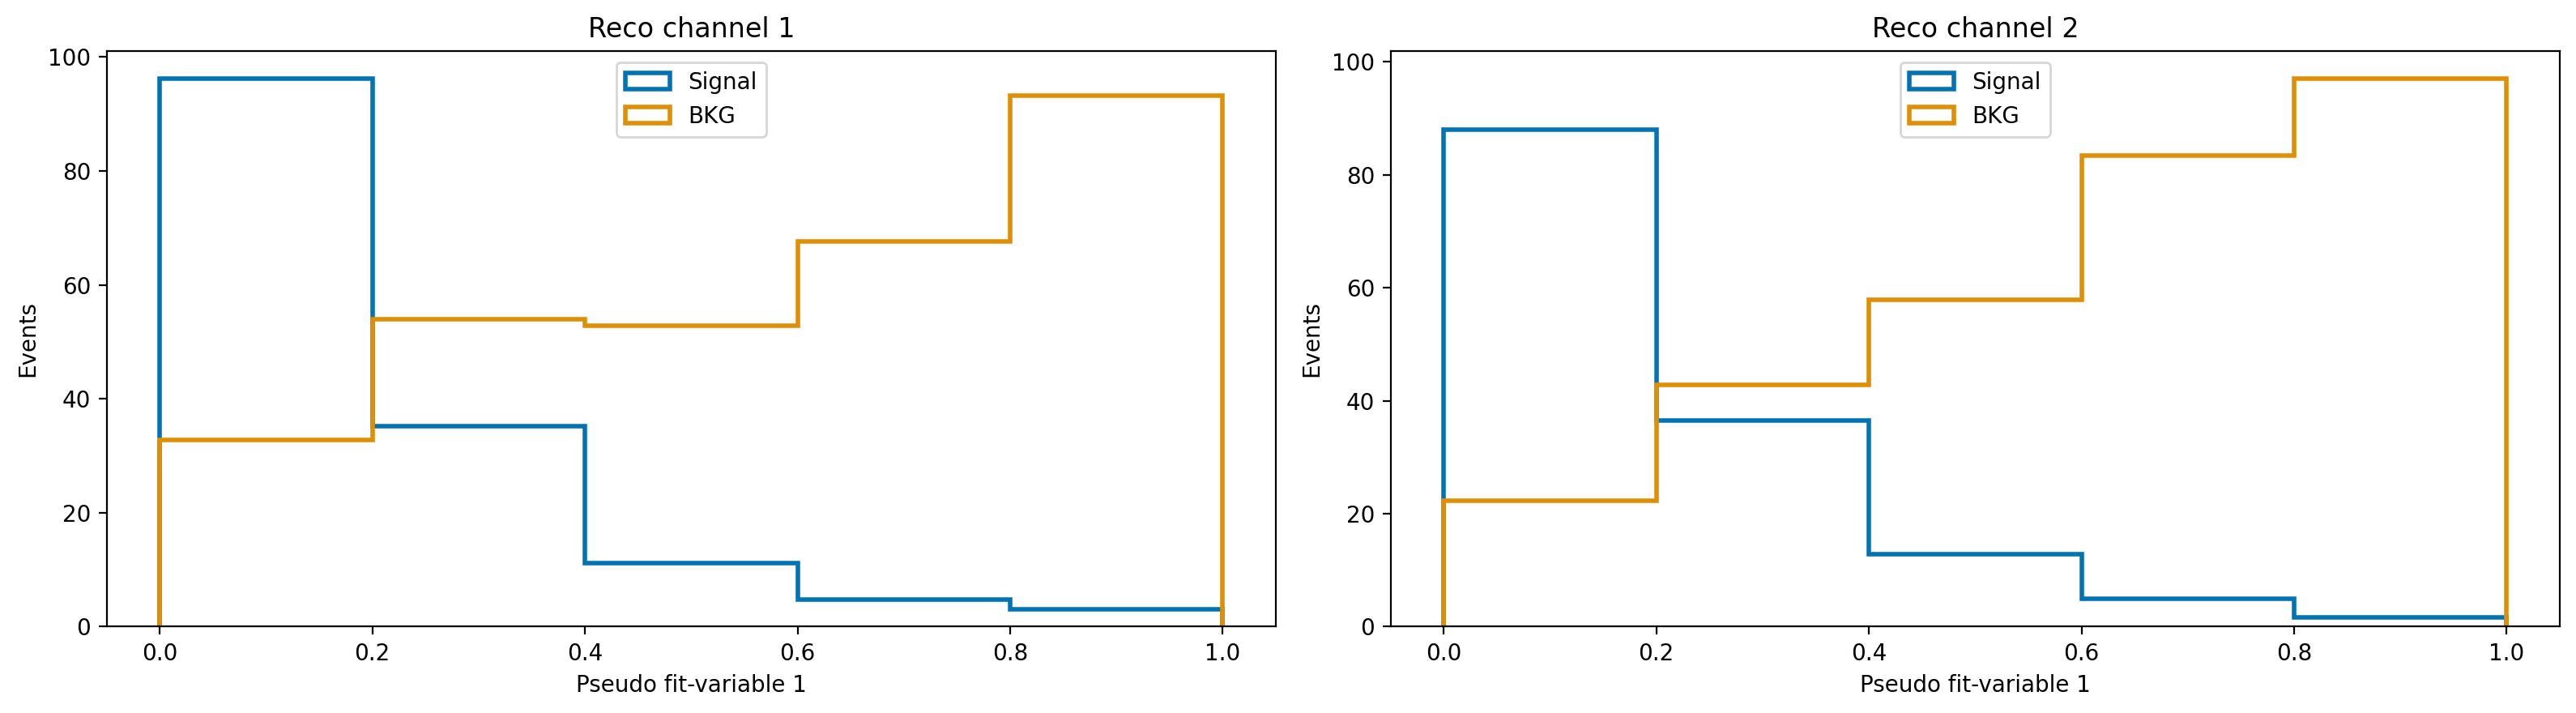

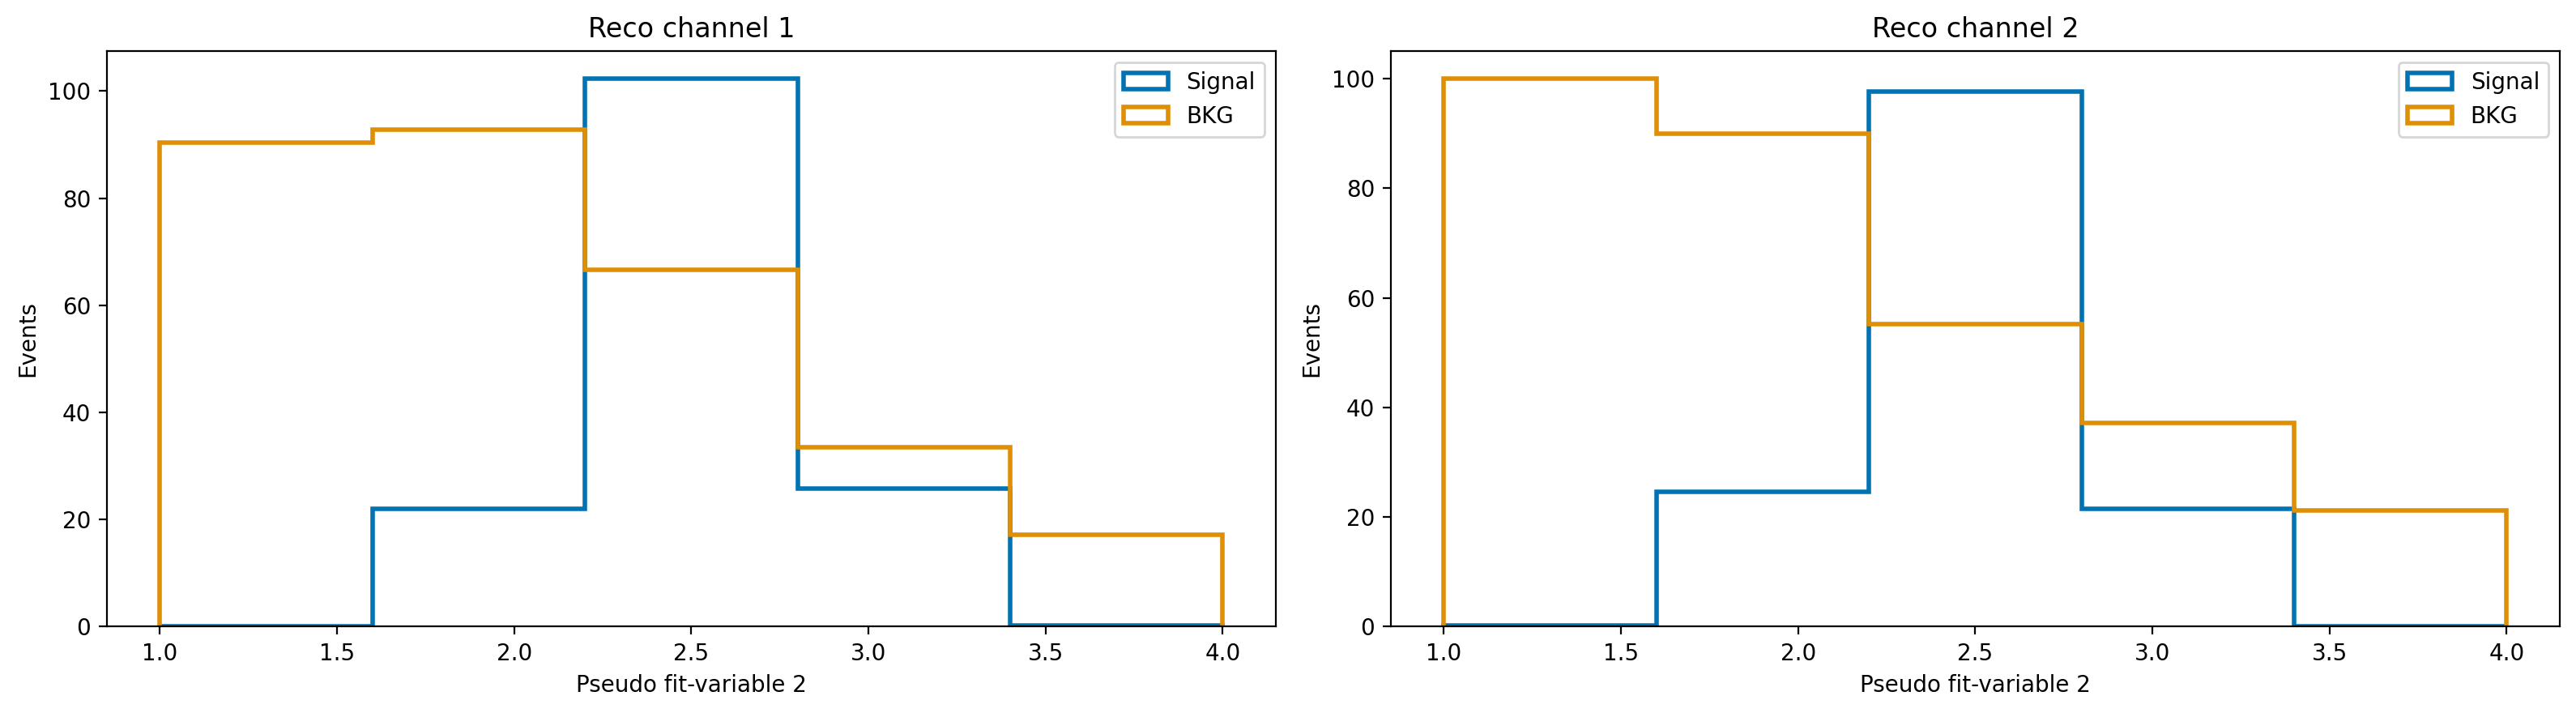

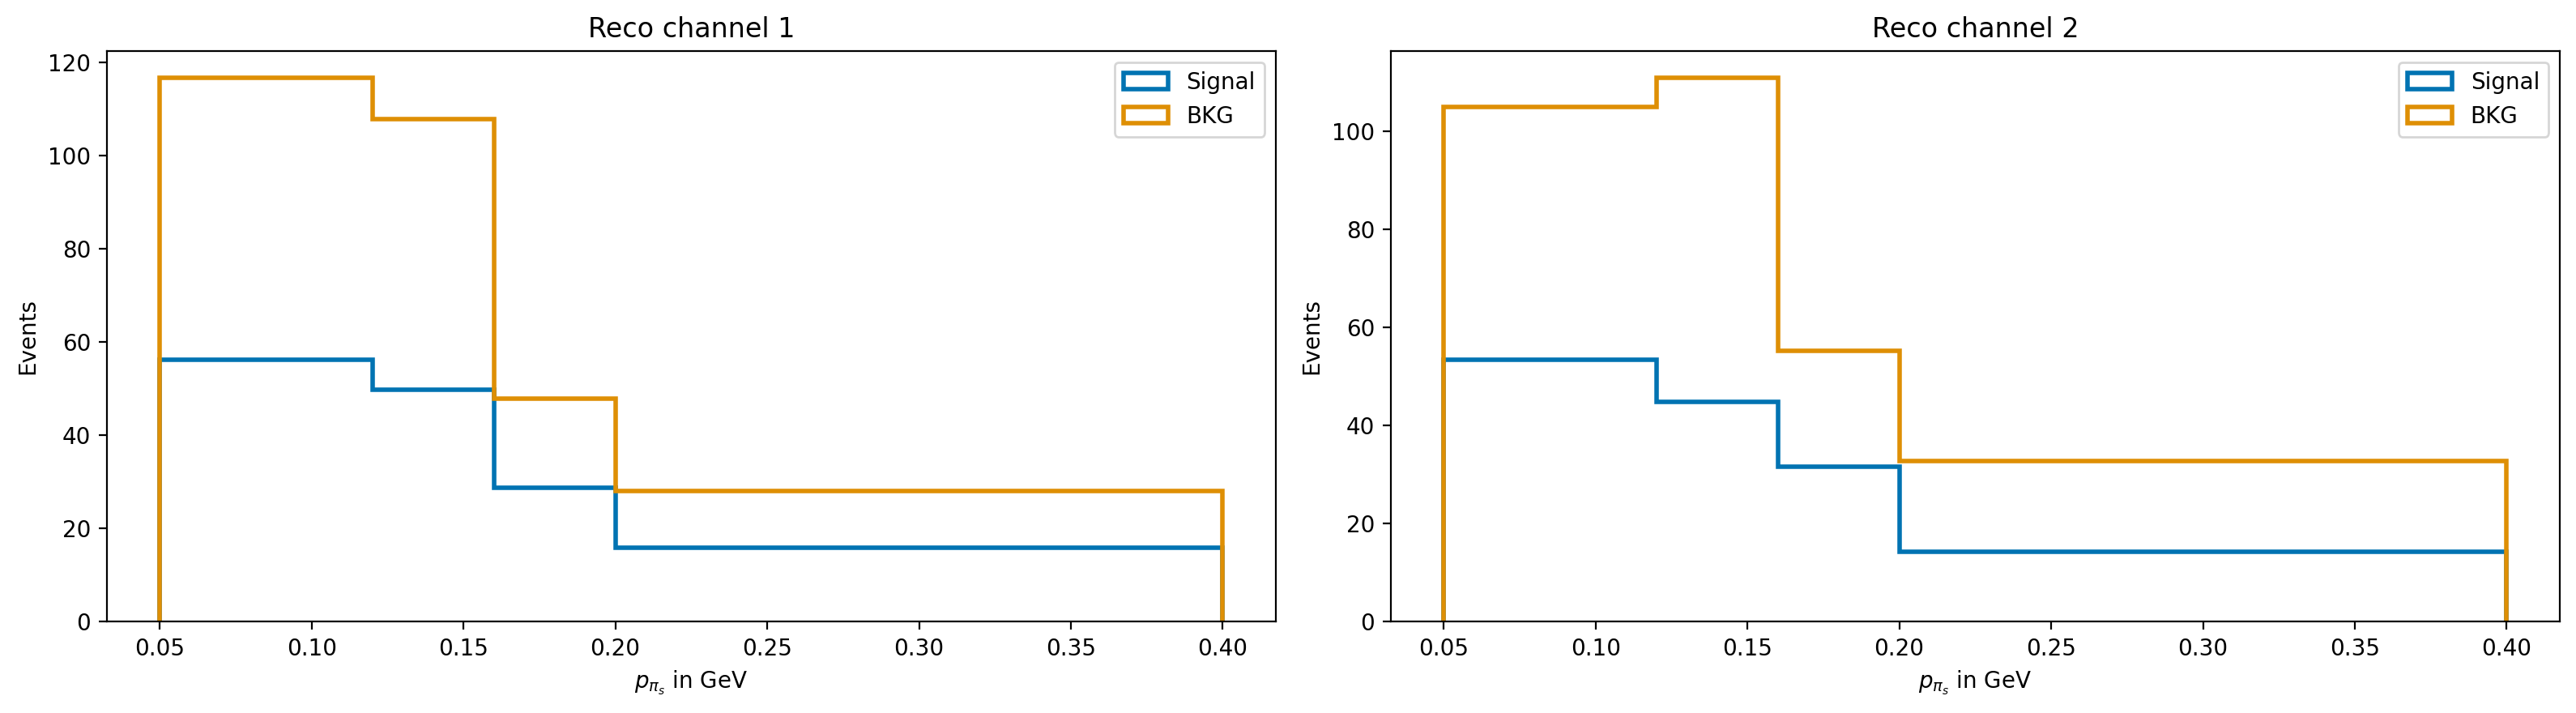

In [5]:
PALETTE = sns.color_palette("colorblind")


def plot_var_in_2_channels(column_name, xlabel, bins, scope):

    fig, ax = plt.subplots(1, 2, figsize = (16, 4.5), dpi = 200)

    for i, c in enumerate(toy_df.channel.value_counts().keys()):
        for j, t in enumerate(toy_df.template.value_counts().keys()):
            tmp_df = toy_df.query(f"channel == {c} & template == '{t}'")
            ax[i].hist(
                tmp_df[column_name],
                weights=tmp_df["total_weight"],
                histtype = "step",
                label = "Signal" if t == "signal" else "BKG",
                bins = bins,
                range = scope,
                linewidth = 2,
                color = PALETTE[j]
            )
        ax[i].legend()
        ax[i].set_xlabel(xlabel)
        ax[i].set_ylabel("Events")
        ax[i].set_title(f"Reco channel {i+1}")


plot_var_in_2_channels("fit_variable1", "Pseudo fit-variable 1", bins = 5, scope = (0,1))
plt.tight_layout()
#plt.savefig("pseudofit1.png", dpi = 200)
plot_var_in_2_channels("fit_variable2", "Pseudo fit-variable 2", bins = 5, scope = (1,4))
plt.tight_layout()
#plt.savefig("pseudofit2.png", dpi = 200)
plot_var_in_2_channels("slow_pi_p", r"$p_{\pi_{s}}$ in GeV", bins = [0.05, 0.12, 0.16, 0.2, 0.4], scope = (0, 0.4))
plt.tight_layout()

### Define the configurations for the Eigen decomposition


### Instructions for the SysVar Configuration File

This configuration file is the primary interface for communicating with SysVar. Your entire analysis setup should be encoded here.

#### Parameters

- **`output_filepath`**:  
  The path where both nominal templates and all template variations will be saved.

- **`reco_channel_id_column`**:  
  The name of the column in your dataframe that distinguishes different reconstruction channels to be fitted separately but simultaneously.

- **`reco_channels`**:  
  A dictionary mapping custom channel names (as keys) to lists of values to be found in the `reco_channel_id_column`.

- **`template_id_column`**:  
  The name of the column in your dataframe that distinguishes different templates.

- **`templates`**:  
  A list of template names. These should correspond to values found in the `template_id_column` of your dataframe.

- **`total_weight`**:  
  The total weight to use when creating nominal templates for your analysis.

- **`MC_prod`**:  
  The Belle II MC campaign. Currently, only `MC15rd` is supported.

- **`Nvar`**:  
  The number of variation weights to generate.

- **`bins`**:  
  A dictionary (of dictionaries) defining the binning for each channel and variable. Both 1D and ND histogram projections are supported.

- **`systematics`**:  
  A dictionary where each key is the name of a systematic.  
    - There should be a corresponding YAML file in the configs (see [configs/MC15rd](https://gitlab.desy.de/itsaklid/sysvar/-/tree/main/configs/MC15rd?ref_type=heads)).
    - The key `weight` should contain the name of the column with the weight associated with this systematic.
    - `prefices`: A string or list of strings to prepend to the weight name to build the column name present in the dataframe.
    - `reco_channels`: Specify a list of channels (as strings) to include or exclude in the systematic variation. If both are `None`, all channels will be affected.
    - `templates`: List of affected templates for this systematic. Defaults to `None` (all templates affected).

---

Please find below the configuration file that corresponds to this mininal example

In [6]:
from sysvar.utils import read_yaml

settings = read_yaml("study_setup_101", "sysvar_101")
settings

{'output_filepath': './test_output.root',
 'reco_channel_id_column': 'channel',
 'reco_channels': {'channel1': [0], 'channel2': [1]},
 'template_id_column': 'template',
 'templates': ['signal', 'bkg'],
 'total_weight': 'total_weight',
 'MC_prod': 'sysvar_101',
 'Nvar': 500,
 'bins': {'channel1': {'fit_variable1': [0, 0.2, 0.4, 0.6, 0.8, 1],
   'fit_variable2': [1, 2, 3, 4]},
  'channel2': {'fit_variable1': [0, 0.2, 0.4, 0.6, 0.8, 1],
   'fit_variable2': [1, 2, 3, 4]}},
 'systematics': {'charged_slow_pi': {'weight': 'charged_weight',
   'prefices': 'slow_pi',
   'reco_channels': {'include': ['channel1', 'channel2'], 'exclude': None},
   'templates': ['signal', 'bkg']}}}

### First let's save the nominal templates. 
This should always be the first step! It should always be prefered that the nominal histograms are saved before any variations in order to avoid problems with uproot's behavior when saving and updating files

In [7]:
from sysvar import save_nominal_templates
save_nominal_templates(toy_df, settings)

INFO : save_nominal_templates: 293 :  Recreate file with uproot: ./test_output.root
INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 518 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 383 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 493 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 385 events
INFO : save_nominal_templates: 301 :  ##################################################
INFO : save_nominal_templates: 302 :  ########## Reco channel: channel1 ##########
INFO : save_nominal_templates: 305 :  ##################################################
INFO : save_nominal_templates: 309 :  Saving Nominal MC template signal in TBranch: channel1/signal/Nominal
INFO : save_nominal_templates: 309 :  Saving Nominal MC template bkg in TBranch: ch

### Let's now perform the eigendecomposition. 
The eigendecompose helper function will return an object which is the only input needed to use the rest of the API

In [8]:
from sysvar import eigendecompose

egd = eigendecompose(
    df = toy_df,
    settings = settings,
    syst_effect = "charged_slow_pi",
    #criterion: "max_differences",
    #prec: 0.005,
    #save_variations: False
)

INFO : read_corrections: 392 :  Loading correction values from config array.
INFO : create_templates: 184 :  ########## Reco channel: channel1 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 518 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 383 events
INFO : create_templates: 184 :  ########## Reco channel: channel2 ##########
INFO : create_templates: 215 :  Building TemplateND for signal from 493 events
INFO : create_templates: 215 :  Building TemplateND for bkg from 385 events
INFO : vary_templates: 162 :  ########## Reco channel: channel1 ##########
INFO : vary_templates: 176 :  Adding variations to signal template
INFO : vary_templates: 176 :  Adding variations to bkg template
INFO : vary_templates: 162 :  ########## Reco channel: channel2 ##########
INFO : vary_templates: 176 :  Adding variations to signal template
INFO : vary_templates: 176 :  Adding variations to bkg template
Building partial covariances:   0%|          | 

**NOTE: `save_nominal_templates` recreates a root file, `save_template_variations` updates an existing root file. So it is very imporant that you first save the nominal templates and only afterwards the template variations.**

We will now try to save the same figure that we had in the previous example. This will fail, but have a look at the end of the error message

MissingMandatorySavingInfo: 
 You are attempting to save a Figure but you're missing the mandatory field top_dir. 
SysVar will not save objects in default locations, or with default names. 
Please call the register_figure_saving_info method in order to specify the necessary information. 
A description of top_dir follows in the next line: 
 The top directory that your objects should be saved in

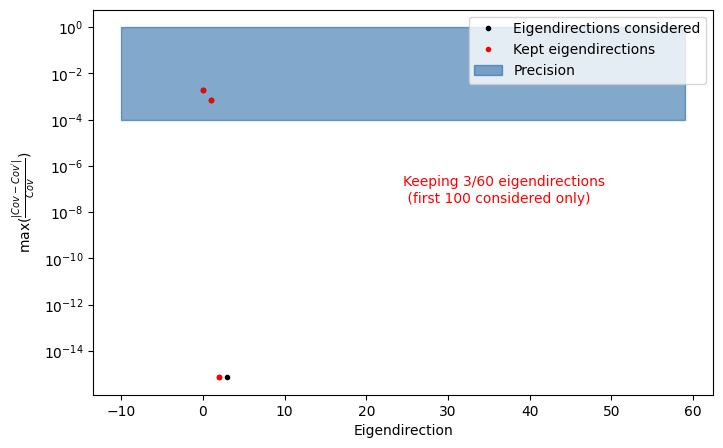

In [9]:
from sysvar import plot_cov_diff
fig, ax= plot_cov_diff(egd, save=True, filename = "test_figure")

In [10]:
from sysvar import register_saving_info

saving_info = {
    "top_dir": "./"
}
register_saving_info(egd, saving_info)

### Now let's try again
Notice that the saving is not failing now, but we are informed that we can more control over the way that the figure are being saved

 You are attempting to save a Figure but you're missing the optional field deep_dir. 
This will not prevent SysVar from saving the Figure, but be aware that you could have more control over your saved object. 
A description of deep_dir follows in the next line: 
 A deeper directory inside the top_dir that specifies the final location of the saved file
 You are attempting to save a Figure but you're missing the optional field extensions. 
This will not prevent SysVar from saving the Figure, but be aware that you could have more control over your saved object. 
A description of extensions follows in the next line: 
 Extra extensions for the file to be saved. For figures this defaults to pdf and png
INFO : save: 247 :  Saved figures in ./


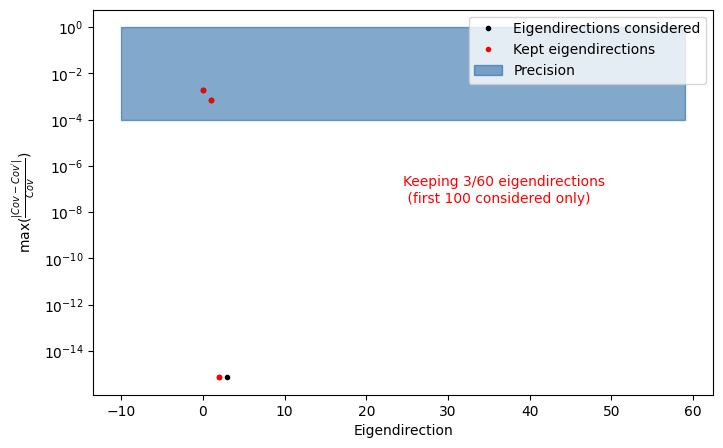

In [11]:
fig, ax= plot_cov_diff(egd, save=True, filename = "test_figure")

### Save the templates in the format cabinetry expects
If you did not enable save_variations = True because you were not sure that you want to save the variation you can still do this since you have access to the eigenvariation object.

In [12]:
# Now save the templates variations throught the EigenDecomposer object
egd.save_template_variations()

INFO : save_template_variations: 294 :  Updating file with uproot: ./test_output.root
INFO : save_template_variations: 306 :  ##################################################
INFO : save_template_variations: 307 :  ########## Reco channel: channel1 ##########
INFO : save_template_variations: 308 :  ##################################################
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/eigendecomposer.py:115: RuntimeWarning: invalid value encountered in sqrt
  return np.real(self.eigen_vectors * np.sqrt(self.eigen_values))
INFO : save_template_variations: 319 :  Saving Up variation of MC template signal in TBranch: channel1/signal/charged_slow_pi_var1_up


INFO : save_template_variations: 330 :  Saving Down variation of signal in TBranch: channel1/signal/charged_slow_pi_var1_down
INFO : save_template_variations: 319 :  Saving Up variation of MC template signal in TBranch: channel1/signal/charged_slow_pi_var2_up
INFO : save_template_variations: 330 :  Saving Down variation of signal in TBranch: channel1/signal/charged_slow_pi_var2_down
INFO : save_template_variations: 319 :  Saving Up variation of MC template signal in TBranch: channel1/signal/charged_slow_pi_var3_up
INFO : save_template_variations: 330 :  Saving Down variation of signal in TBranch: channel1/signal/charged_slow_pi_var3_down
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/eigendecomposer.py:115: RuntimeWarning: invalid value encountered in sqrt
  return np.real(self.eigen_vectors * np.sqrt(self.eigen_values))
INFO : save_template_variations: 319 :  Saving Up variation of MC template bkg in TBranch: channel1/bkg/charged_slow_pi_var1_up
INFO : save_template_v

This will save the template variations in the same root file that you saved the nominal templates earlier.




Let's examine a bit more closely the templates that we have created

/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/visualize.py:725: RuntimeWarning: invalid value encountered in divide
  h_up[0].flatten() / self.instance.nom_hist[0].flatten(),
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/visualize.py:733: RuntimeWarning: invalid value encountered in divide
  h_down[0].flatten() / self.instance.nom_hist[0].flatten(),
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/visualize.py:757: RuntimeWarning: invalid value encountered in divide
  (h_up[0].flatten() - self.instance.nom_hist[0].flatten())
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/visualize.py:725: RuntimeWarning: invalid value encountered in divide
  h_up[0].flatten() / self.instance.nom_hist[0].flatten(),
/Users/agrimaggarwal/Documents/PhD/frameworks/sysvar/src/sysvar/visualize.py:733: RuntimeWarning: invalid value encountered in divide
  h_down[0].flatten() / self.instance.nom_hist[0].flatten(),
/Users/agrimaggarwal/Documents

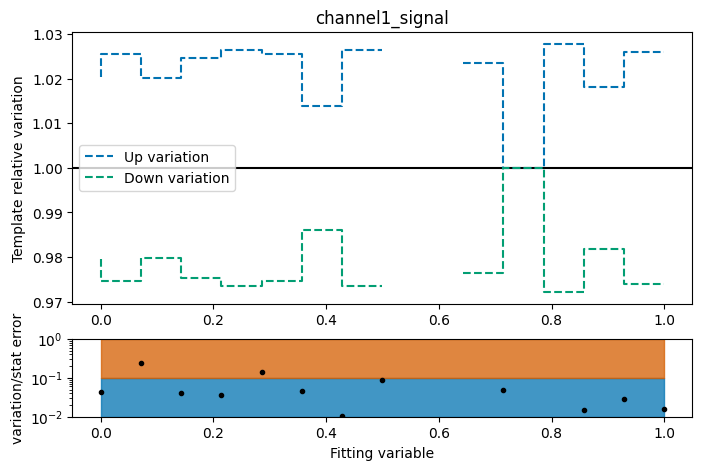

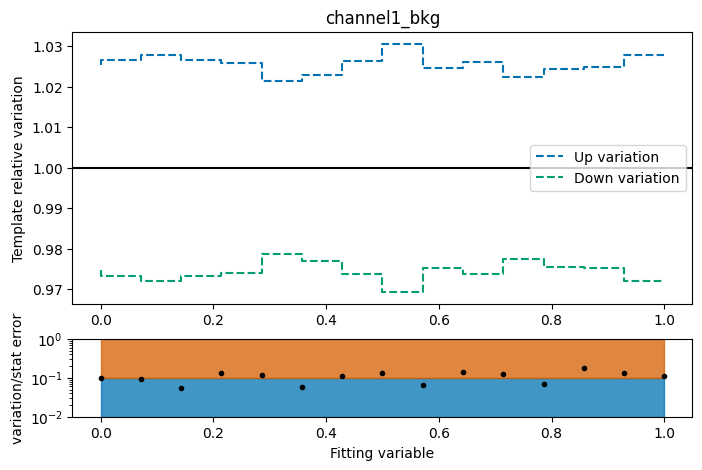

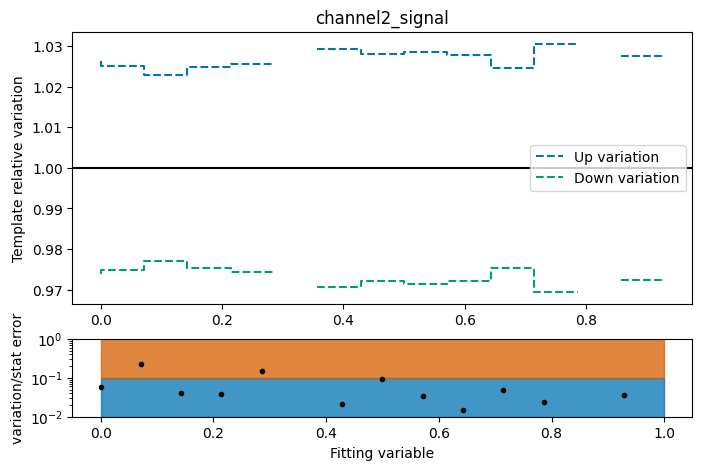

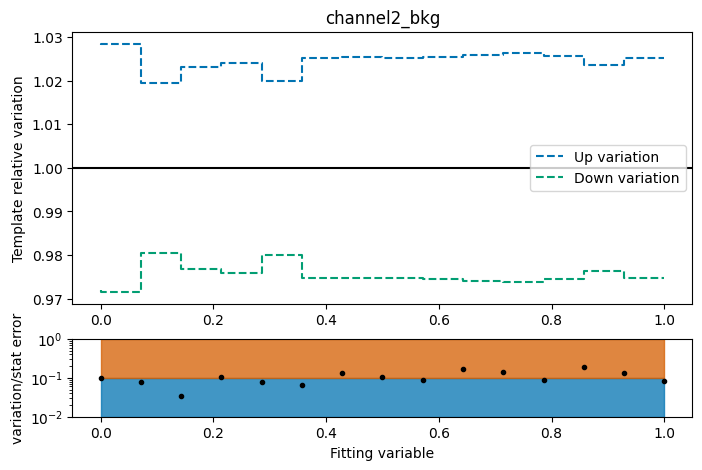

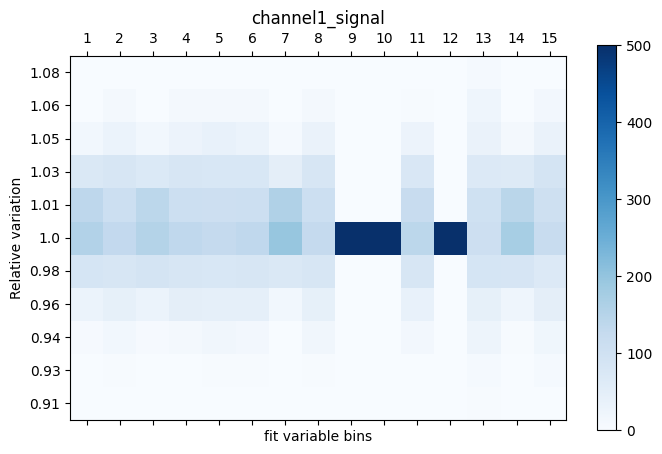

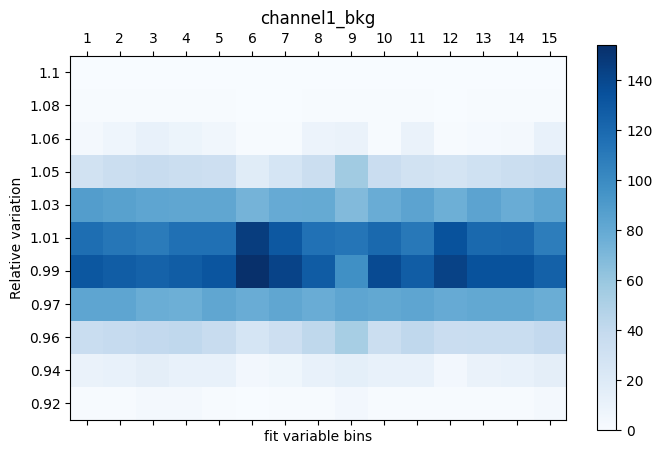

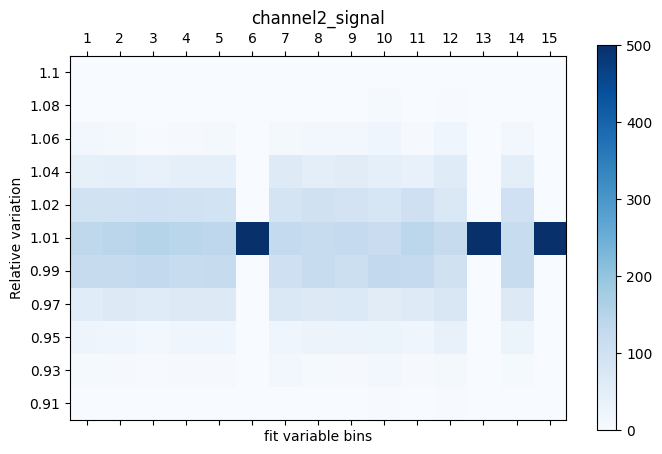

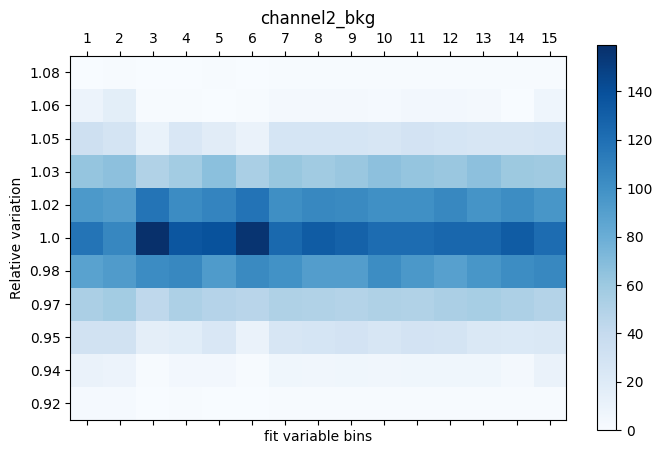

In [13]:
from sysvar import plot_templates_relative_variations_in_grid, plot_up_and_down_variations
figures1= plot_up_and_down_variations(egd)
figures2= plot_templates_relative_variations_in_grid(egd)

### Now how did we get those variations ? 

### Every EigenDecomposer object creates a Variator object which implements a covariance matrix between the different correction bins

This ensures that the variations that we sample from are common for every template

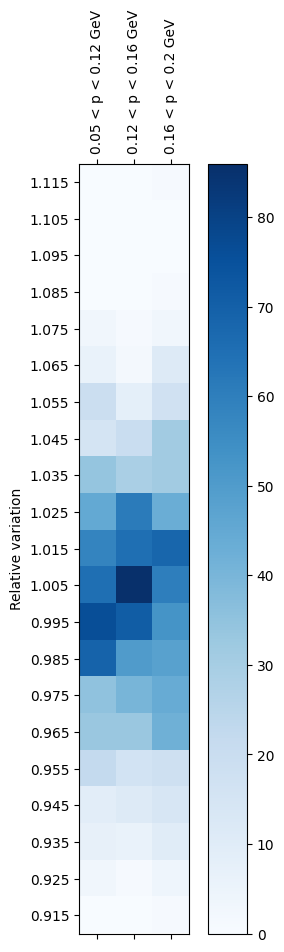

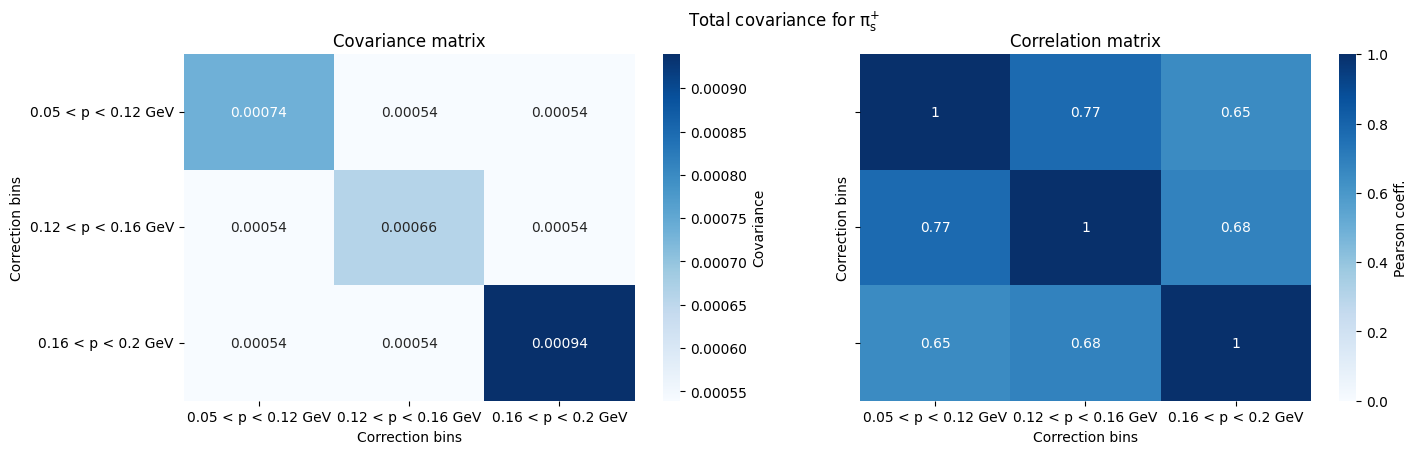

In [14]:
from sysvar import plot_correction_variations_in_grid, plot_correction_cov_and_corr
fig1, ax1= plot_correction_variations_in_grid(egd)
fig2, ax2= plot_correction_cov_and_corr(egd)

### What about the corrections itself ? 

SysVar provides a visualisation method to inspect the central correction values together with their uncertainties.

*All visualisation methods return the Matplotlib figure and axes objects, so you have full freedom to modify the plots after SysVar has created them.*

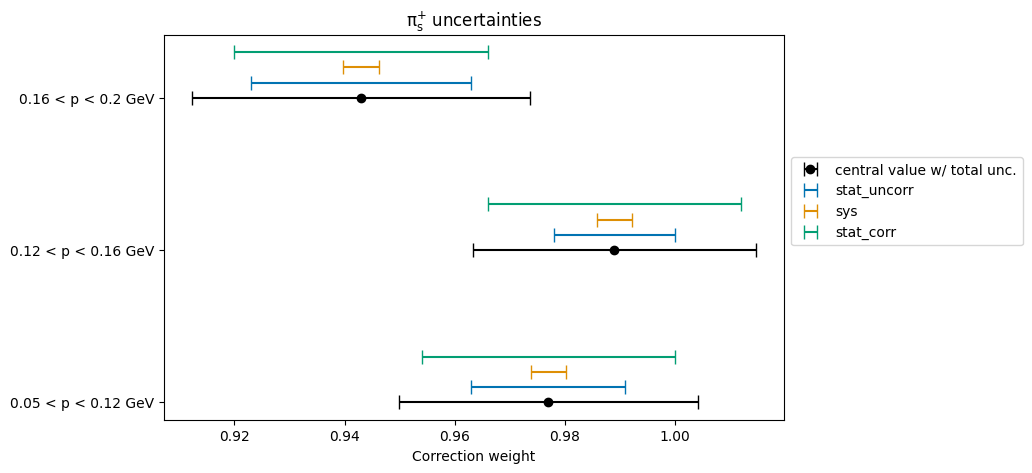

In [15]:
from sysvar import plot_correction_errors
fig, ax= plot_correction_errors(egd)